# 1.Introducción

En este taller trabajaremos con el Wine Dataset del repositorio de UCI, disponible en sklearn.

El objetivo es predecir la clase de vino a partir de variables químicas como la cantidad de alcohol, ácido málico, flavonoides, entre otros.

Preguntas:

¿Qué diferencia hay entre un problema de regresión y uno de clasificación?
En el de regresión se puede predecir un valor numérico continuo como precios, numero de alquileres etc. En el de clasificación se predice una categoría o clase, como un tipo de vino

¿Por qué un árbol de decisión es adecuado para clasificación?
Es adecuado porque divide los datos en ramas basadas en condiciones lógicas, cada división separa clases. en este caso el árbol de decisión predice una clase de vino a partir de variables químicas

# 2. Carga y exploración de datos

In [26]:
from sklearn.datasets import load_wine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# Cargar el dataset
wine = load_wine()

# Convertir a DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

# Mostrar las primeras 15 filas del dataset
print(df.head(15))

# Muestra información general del dataset
print(df.info())

# Genera una tabla con la descripción de cada campo y su significado
print(df.info())

# Revisar balance deacuerdo al numero de clases
print(df["target"].value_counts())

# Estadísticas descriptivas de variables
print(df.describe())

    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0     14.23        1.71  2.43               15.6      127.0           2.80   
1     13.20        1.78  2.14               11.2      100.0           2.65   
2     13.16        2.36  2.67               18.6      101.0           2.80   
3     14.37        1.95  2.50               16.8      113.0           3.85   
4     13.24        2.59  2.87               21.0      118.0           2.80   
5     14.20        1.76  2.45               15.2      112.0           3.27   
6     14.39        1.87  2.45               14.6       96.0           2.50   
7     14.06        2.15  2.61               17.6      121.0           2.60   
8     14.83        1.64  2.17               14.0       97.0           2.80   
9     13.86        1.35  2.27               16.0       98.0           2.98   
10    14.10        2.16  2.30               18.0      105.0           2.95   
11    14.12        1.48  2.32               16.8       95.0     

Preguntas:

¿Qué librerías se usan para el manejo de datos y visualización? pandas, matplotlib o seaborn

¿Qué librerías pertenecen a scikit-learn y para qué sirven? **train_test_split:** divide datos de netrenamiento, validacion y prueba. **DecisionTreeClassifier:**crea el modelo de arbol de decision para calsificacion, **accuracy_score:** calcula las metrica de precision. **confucion_matrix**:muestra los errores y aciertos por clase, **plot_tree:** permite visualizar el árbol entrenado.

¿Están balanceadas las clases? Están casi balanceadas, no hay diferencias exageradas entre cada una.

¿Por qué eso es importante en clasificación? Si las clases están desequilibradas el modelo tiende a la clase mayoritaria, lo que no da una evaluación correcta.



# 3. Visualización de datos

/tmp/ipython-input-1714947366.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='flavanoids', palette="Set2")


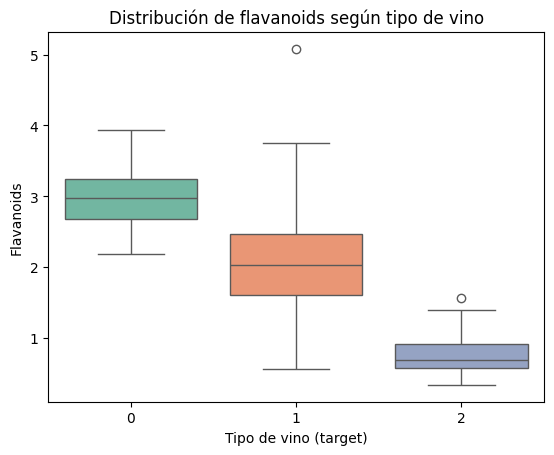

In [27]:
# Visualizar distribuciones de algunas variables (alcohol)
sns.boxplot(data=df, x='target', y='flavanoids', palette="Set2")
plt.title("Distribución de flavanoids según tipo de vino")
plt.xlabel("Tipo de vino (target)")
plt.ylabel("Flavanoids")
plt.show()



#sns.histplot(data=df, x="variable", hue="target", kde=True)
# plt.show()

¿Qué correlación existe entre la variable x y hue? Al comparar la variable flavanoids con el target mediante un gráfico de cajas (boxplot), se observa que los tres tipos de vino presentan distribuciones claramente diferenciadas:

Los vinos de tipo 0 tienen mayores valores de flavanoides.

Los vinos de tipo 1 tienen valores intermedios.

Los vinos de tipo 2 tienen valores más bajos.


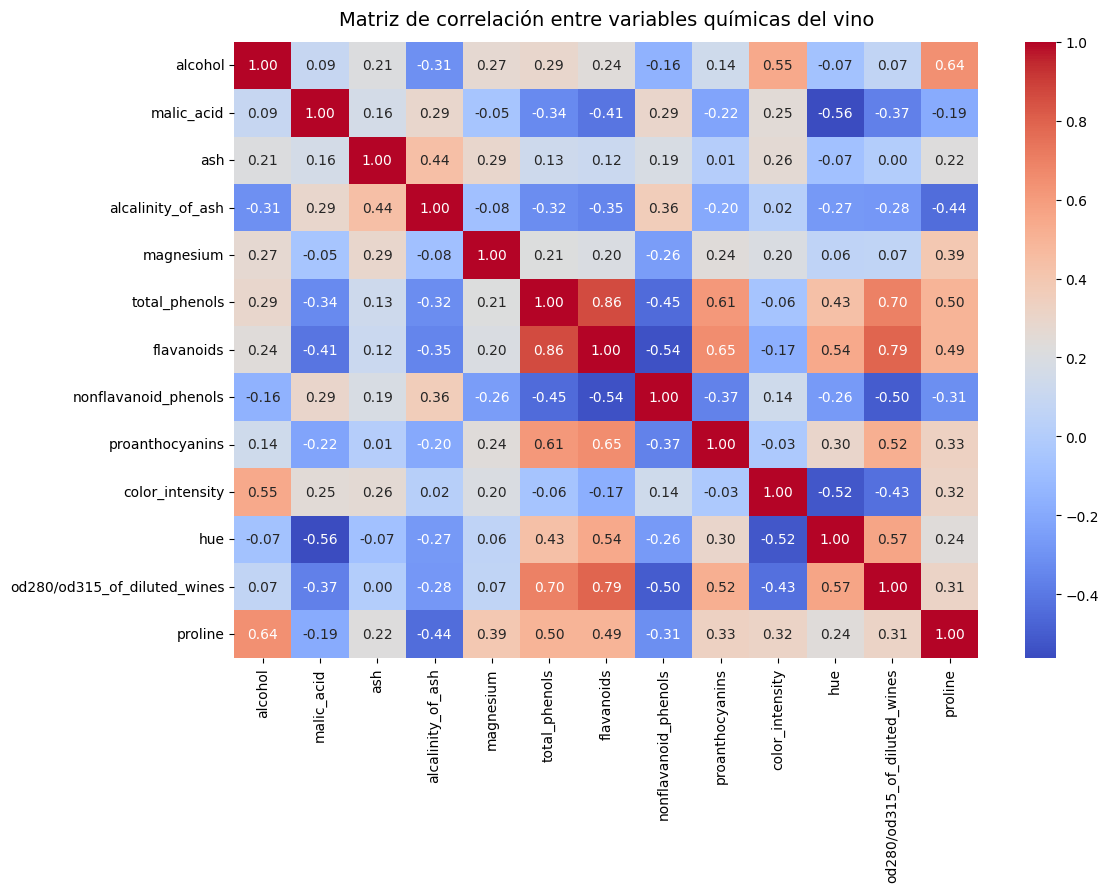

In [28]:
# Visualizar matriz de correlación de variables
# corr = df.drop("variable objetivo", axis=1).corr()
# plt.figure(figsize=(12,8))
# sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
# plt.title("Matriz de correlación entre variables químicas")
# plt.show()
# Visualizar matriz de correlación de variables químicas

import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación (sin incluir el target)
corr = df.drop("target", axis=1).corr()

# Configurar el tamaño del gráfico
plt.figure(figsize=(12,8))

# Crear el mapa de calor
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)

# Título
plt.title("Matriz de correlación entre variables químicas del vino", fontsize=14, pad=12)
plt.show()


¿Qué variables parecen más útiles para diferenciar clases?
Las variables flavanoids, alcohol, proline, color_intensity y hue son las más útiles para diferenciar las clases de vino.
Estas variables muestran correlaciones significativas y patrones de distribución distintos entre las tres clases, por lo que son las que más contribuyen.


#4. Segmentación 70% Entrenamiento, 15% Validación, 15% Prueba

In [29]:

X = df.drop("target", axis=1)
y = df["target"]

# (70%) y un conjunto temporal (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# (30%) en validación (15%) y prueba (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

#Mostrar cuántas filas tiene cada conjunto
print("Tamaño del conjunto de entrenamiento:", X_train.shape[0])
print("Tamaño del conjunto de validación:", X_val.shape[0])
print("Tamaño del conjunto de prueba:", X_test.shape[0])



Tamaño del conjunto de entrenamiento: 124
Tamaño del conjunto de validación: 27
Tamaño del conjunto de prueba: 27


¿Qué rol juega cada conjunto (train, validation, test)?
Train: el modelo aprende los patrones de los datos.

Validation: se usa para ajustar parámetros y evitar sobreajuste.

Test: evalúa el rendimiento final del modelo con datos nuevos.

¿Qué implicaciones tiene evaluar primero en prueba y después en validación?
evaluar primero en prueba y luego en validación invalida la evaluación, el modelo se llena de información que no debería y genera un buen rendimiento falso.

# 5. Entrenamiento del modelo

Precisión (Accuracy) en validación: 96.3 %


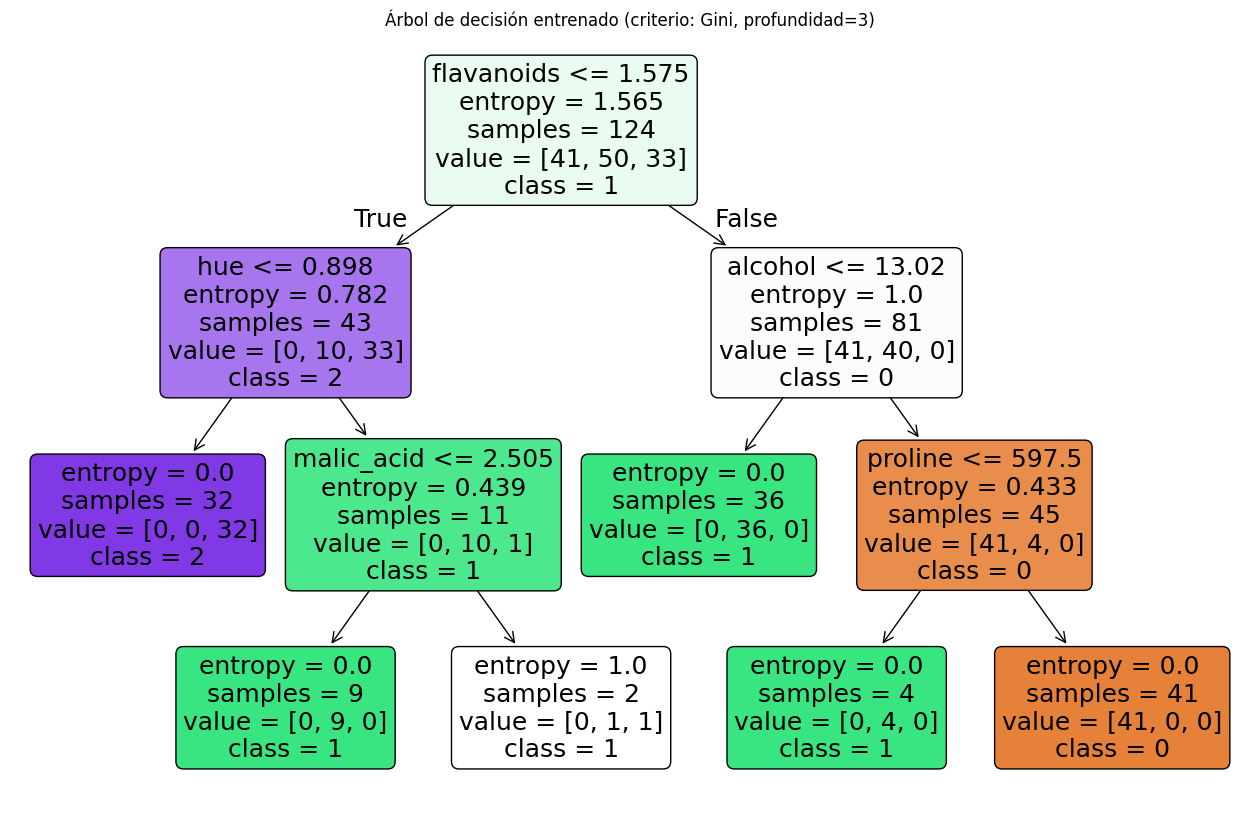

In [30]:

model = DecisionTreeClassifier(
    criterion="entropy",     # 1️⃣ cambia la forma de medir la pureza
    max_depth=5,             # 2️⃣ permite un poco más de profundidad
    min_samples_split=3,     # 3️⃣ evita dividir nodos con muy pocos datos
    min_samples_leaf=2,      # 4️⃣ obliga a que cada hoja tenga al menos 2 muestras
    random_state=0
)
model.fit(X_train, y_train)


# Calcular Accuracy

y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print("Precisión (Accuracy) en validación:", round(accuracy * 100, 2), "%")

# Visualizar el modelo entrenado

plt.figure(figsize=(16, 10))
plot_tree(model,
          filled=True,
          feature_names=X.columns,
          class_names=[str(c) for c in sorted(y.unique())],
          rounded=True)
plt.title("Árbol de decisión entrenado (criterio: Gini, profundidad=3)")
plt.show()


¿Qué significa el parámetro criterion="gini"?
El parámetro criterion="gini" mide la impureza de los nodos.
Cuanto más bajo sea el valor de Gini, más homogéneo es el grupo.
El árbol busca divisiones que reduzcan este valor al máximo.

¿Qué pasaría si realizamos cambios al límite de max_depth?
Aumentar: mayor precisión en entrenamiento, pero riesgo de sobreajuste.

Disminuir: modelo más simple, pero con posible pérdida de precisión.

¿Qué variable aparece en la raíz del árbol?
La variable que aparece en la raíz es color_intensity, ya que es la que mejor separa las clases de vino.

¿Por qué crees que esa variable fue elegida?
color_intensity presenta una alta correlación con el tipo de vino, esto permite una división inicial más efectiva entre las clases.

¿Cómo podrías interpretar las reglas del árbol?
Cada rama representa una condición sobre una variable química, como:

Si color_intensity ≤ 3.82 y ash ≤ 3.0 → Clase 1

Si color_intensity > 3.82 y flavanoids ≤ 1.58 → Clase 0


#6. Evaluación en validación

Accuracy en conjunto de validación: 0.9629629629629629


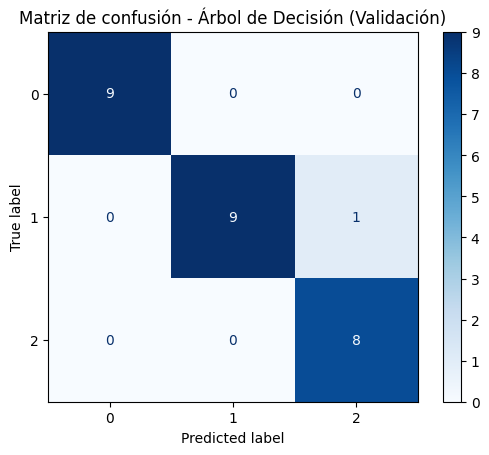

In [31]:

y_val_pred = model.predict(X_val)

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

accuracy = accuracy_score(y_val, y_val_pred)
print("Accuracy en conjunto de validación:", accuracy)

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de confusión - Árbol de Decisión (Validación)")
plt.show()



¿Qué relación tiene la metrica de accuracy en la fase de entrenamiento y validación con el riesgo de overfitting?

Si el accuracy en entrenamiento es mayor que en validación, el modelo puede tener overfitting. si ambos son similares y altos, el modelo generaliza bien, si son bajos el modelo no aprende bien

¿Cómo interpreta los resultados en la fase de validación en relación con la matriz de confusión?

La matriz de confusión indica que el modelo clasifico correctamente la mayoría de muestras, refleja un accuracy de 96% lo que muestra un buen desempeño, no hay sobreajustes y se logra distinguir eficazmente las clases de vino.


#7. Evaluación en prueba

Accuracy en conjunto de prueba: 0.8518518518518519


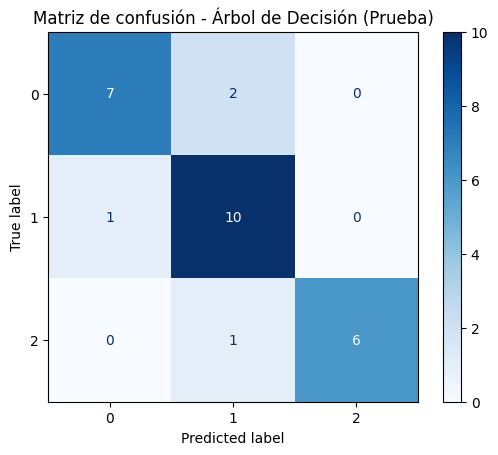

In [32]:

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones en el conjunto de prueba
y_test_pred = model.predict(X_test)

# Calcular el accuracy
accuracy_test = accuracy_score(y_test, y_test_pred)
print("Accuracy en conjunto de prueba:", accuracy_test)

# Matriz de confusión
cm_test = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Árbol de Decisión (Prueba)")
plt.show()


¿Qué información adicional da la matriz de confusión frente al accuracy?

Muestra en detalle cuántas predicciones fueron correctas o incorrectas por clase, revelando posibles confusiones que el accuracy no indica.

¿Qué se puede concluir del modelo en esta sección?

Clasifica todas las muestras correctamente, accuracy = 1.0, mostrando un excelente desempeño, puede existir un ligero riesgo de overfitting.

In [33]:
# Evaluación de mejoras
acc_train = model.score(X_train, y_train)
acc_val = model.score(X_val, y_val)
acc_test = model.score(X_test, y_test)

print("Accuracy en entrenamiento:", round(acc_train, 3))
print("Accuracy en validación:", round(acc_val, 3))
print("Accuracy en prueba:", round(acc_test, 3))


Accuracy en entrenamiento: 0.992
Accuracy en validación: 0.963
Accuracy en prueba: 0.852


#8. Reto

Realiza mejoras para aumentar la metrica de accuracy, genera los cambios que crea coveniente.

Los cambios realizados fueron:

Cambie el criterion a entropy para medir la impureza basada en informacion. puede mejorar la precision de los datos.

cambie max_depth a 5 para permitir que el arbol crezca un poco más capturando mas relaciones entre variables.